In [95]:
library(tidyverse)
library(ggplot2)
library(ggpubr)
library(readr)
library(survival)
library(survminer)
library(stringr)
library(ComplexHeatmap)
library(ggrepel)
library(survminer)
library(survival)
library(RColorBrewer)
library(circlize)
library(data.table)
library(scales)
library(data.table)
library(cowplot)
library(patchwork)
library(ggpubr)
library(ggbeeswarm)
library(rstatix)
source("../survival_analysis/utils/helpers.R")


## Results dir

In [2]:
data_dir = "/Users/jawadalaaedeen/Desktop/PhD/NMC/results"
results_dir = "/Users/jawadalaaedeen/Desktop/PhD/NMC/results/supp_figs"

# Palette

In [105]:
myeloid_palette <- c(
  "MDSCs" = "#332288",
  "M2-like macrophages" = "#66A61E",
  "M1-like macrophages" = "#00557F",
  "M1/M2-like macrophages" = "#BBCCEE",
  "DCs" = "#E69F00",
  "Granulocytes" = "#B85AA6",
  "Mast cells" = "#8E006A"
)

lymphoid_palette <- c(
  "CD8+ T cells" = "#B2182B",
  "CD4+ T cells" = "#EF8A62",
  "Treg T cells" = "#FFCCCC",
  "NK cells" = "#0096FF",
  "B cells" = "#E6C84F",
  "PCs" = "#F4E58A"
)

non_immune_palette <- c(
  "Actin+ cells" = "#B39DDB",
  "Endothelial cells" = "#7F8F6A",
  "Lymphatic endothelial cells" = "#A6B08A",
  "Epithelial cells" = "#E3B07A"
)


other_palette <- c(
  "Tumor cells" = "#44AA99",
  "NFC" = "#DDDDDD"
)

full_palette <- c(
  myeloid_palette,
  lymphoid_palette,
  non_immune_palette,
  other_palette
)

tumor_site_colors <- c(
"Lung" = "#F0F0F0",     # very light
"Head and Neck" = "#B0B0B0",  # medium
"Extrahepatic" = "#505050" # darker
)

# Survival group colors
surv_colors <- c(
  "Short-term survivor" = "#E07B7B",
  "Long-term survivor"  = "#6BAED6"
)


main_group_colors <- c(
  "Myeloid"  = "#332288",
  "Lymphoid" = "#B2182B",
  "Non-immune" = "#B39DDB",
  "Tumor" = "#44AA99",
  "NFC" = "#DDDDDD"
)

color_for_ratios <- c(
  "Granulocytes-T cells ratio"    = "#B85AA6",
  "Macrophages-T cells ratio" = "#66A61E",
  "MDSCs-T cells ratio" = "#332288"
)

gvsm2_colors = c(
    "< Granulocytes" = "#B85AA6",
    "< M2-like macrophages" = "#66A61E"
)

# Loading Primary dataset

In [6]:
celltype_metadata <- readr::read_csv(
  paste0(data_dir, "/celltype_metadata_final.csv")
) %>%
  filter(!patient_exp %in% c("NMC_6_ROI6", "NMC_12_ROI6", "NMC_21_ROI23")) %>%
  mutate(is_lung = ifelse(tumor_site == "Lung", "Lung", "Head and Neck/Extrahepatic")) %>%
  mutate("patient_ID" = str_replace(patient_ID, "NMC", "NUT"),
         "patient_exp" = str_replace(patient_exp, "NMC", "NUT"))

#patient exp are written basically like this: NUT_2_ROI3 etc.. let's arrange them properly so based on patient number and then ROI number and extract that order
celltype_metadata <- celltype_metadata %>%
  mutate(patient_num = as.numeric(str_extract(patient_exp, "(?<=NUT_)\\d+")),
         roi_num = as.numeric(str_extract(patient_exp, "(?<=ROI)\\d+"))) %>%
  arrange(patient_num, roi_num) %>%
  select(-patient_num, -roi_num)
celltype_metadata$patient_exp <- factor(celltype_metadata$patient_exp, levels = unique(celltype_metadata$patient_exp))
celltype_metadata$patient_ID <- factor(celltype_metadata$patient_ID, levels = unique(celltype_metadata$patient_ID))
patient_ID_order <- unique(celltype_metadata$patient_ID)
patient_exp_order <- unique(celltype_metadata$patient_exp)


myeloid <-  c("M1 macrophages", "M2 macrophages", "M1/M2 macrophages", "DCs", "Granulocytes", "MDSCs", "Mast cells")
lymphoid <- c("CD4+ T cells", "CD8+ T cells", "Treg T cells", "NK cells", "B cells", "PCs")
nonimmune <- c("Actin+ cells", "Endothelial cells", "Lymphatic endothelial cells", "Epithelial cells")

celltype_metadata <- celltype_metadata %>%
  mutate(
    cell_category_simplified = case_when(
      cell_category %in% myeloid ~ "Myeloid",
      cell_category %in% lymphoid ~ "Lymphoid",
      cell_category %in% nonimmune ~ "Non-immune",
      cell_category == "NFC" ~ "NFC",
      cell_category == "Tumor cells" ~ "Tumor"
    ),
    cell_category_simplified = factor(
      cell_category_simplified,
      levels = c("NFC", "Non-immune", "Lymphoid", "Myeloid", "Tumor")
    )
  ) 

Rows: 553331 Columns: 17
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (10): cell_type, cell_category, patient_ID, exp_name, patient_exp, tumor...
dbl  (7): cell_id, Cell Center X, Cell Center Y, run, rois, survival_time_mo...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [13]:
survival_df <- read.csv(
    paste0(data_dir, "/survival_data.csv")
) %>%
#add a factor order for tumor_site column
mutate(tumor_site = factor(tumor_site, levels = c("Lung", "Head and Neck", "Extrahepatic")),
patient_ID = factor(patient_ID, levels = patient_ID_order),
is_lung = ifelse(tumor_site == "Lung", "Lung", "Head and Neck/Abdomen"),
survival_group = ifelse(survival_time_months > 6, "Long-term survivor", "Short-term survivor"),
    event = as.numeric(event),
    survival_time_months = as.numeric(survival_time_months)
  )

survival_df_order <- survival_df %>%
mutate(tumor_site = factor(tumor_site, levels = c("Lung", "Head and Neck", "Abdomen"))) %>%
arrange(tumor_site, survival_time_months) %>%
mutate(patient_ID = factor(patient_ID, levels = unique(patient_ID))) 

patient_ID_survival_order <-survival_df_order %>%
pull(patient_ID)

In [8]:
#showcase proportions of celltypes per patient_exp in a stacked barplot
celltype_percentage_exp <- celltype_metadata %>%
  select(patient_exp, patient_ID, cell_category_simplified, cell_category) %>%
  group_by(patient_exp, patient_ID, cell_category_simplified, cell_category) %>%
  summarise(cell_count = n()) %>%
  ungroup() %>%
  group_by(patient_exp, patient_ID) %>%
  mutate(
    proportion = ifelse(cell_count == 0, NA, cell_count / sum(cell_count)),
    percentage = ifelse(cell_count == 0, NA, (cell_count / sum(cell_count)) * 100),
    geom_mean = exp(mean(log(proportion), na.rm = TRUE)), 
    clr = log(proportion / geom_mean)
  ) %>%
  ungroup()

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by patient_exp, patient_ID,
  cell_category_simplified, and cell_category.
ℹ Output is grouped by patient_exp, patient_ID, and cell_category_simplified.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(patient_exp, patient_ID, cell_category_simplified,
  cell_category))` for per-operation grouping (`?dplyr::dplyr_by`) instead.


In [9]:
#get percentages of cell types per patient
cellgroup_percentage_patient = celltype_percentage_exp %>%
  group_by(patient_exp, patient_ID, cell_category_simplified) %>%
  #get the sum of the cell_category_simplified percentages
    summarise(cell_count = sum(cell_count)) %>%
    ungroup() %>%
    group_by(patient_exp, patient_ID) %>%
    mutate(
        proportion = ifelse(cell_count == 0, NA, cell_count / sum(cell_count)),
        percentage = ifelse(cell_count == 0, NA, (cell_count / sum(cell_count)) * 100),
        geom_mean = exp(mean(log(proportion), na.rm = TRUE)), 
        clr = log(proportion / geom_mean)
      ) %>%
    ungroup() %>%
    group_by(patient_ID, cell_category_simplified) %>%
    summarise(percentage = median(percentage),
              clr = median(clr)) %>%
    ungroup()

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by patient_exp, patient_ID, and
  cell_category_simplified.
ℹ Output is grouped by patient_exp and patient_ID.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(patient_exp, patient_ID, cell_category_simplified))`
  for per-operation grouping (`?dplyr::dplyr_by`) instead.
`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by patient_ID and cell_category_simplified.
ℹ Output is grouped by patient_ID.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(patient_ID, cell_category_simplified))` for
  per-operation grouping (`?dplyr::dplyr_by`) instead.


In [10]:
#get percentages of cell types per patient
celltype_percentage_patient = celltype_percentage_exp %>%
  group_by(patient_exp, patient_ID, cell_category, cell_category_simplified) %>%
  #get the sum of the cell_category_simplified percentages
    summarise(cell_count = sum(cell_count)) %>%
    ungroup() %>%
    group_by(patient_exp, patient_ID) %>%
    mutate(
        proportion = ifelse(cell_count == 0, NA, cell_count / sum(cell_count)),
        percentage = ifelse(cell_count == 0, NA, (cell_count / sum(cell_count)) * 100),
        geom_mean = exp(mean(log(proportion), na.rm = TRUE)), 
        clr = log(proportion / geom_mean)
      ) %>%
    ungroup() %>%
    group_by(patient_ID, cell_category, cell_category_simplified) %>%
    summarise(percentage = median(percentage),
              clr = median(clr)) %>%
    ungroup()
celltype_percentage_patient

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by patient_exp, patient_ID, cell_category,
  and cell_category_simplified.
ℹ Output is grouped by patient_exp, patient_ID, and cell_category.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(patient_exp, patient_ID, cell_category,
  cell_category_simplified))` for per-operation grouping (`?dplyr::dplyr_by`)
  instead.
`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by patient_ID, cell_category, and
  cell_category_simplified.
ℹ Output is grouped by patient_ID and cell_category.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(patient_ID, cell_category, cell_category_simplified))`
  for per-operation grouping (`?dplyr::dplyr_by`) instead.


patient_ID,cell_category,cell_category_simplified,percentage,clr
<fct>,<chr>,<fct>,<dbl>,<dbl>
NUT_1,Actin+ cells,Non-immune,4.58263187,1.59803591
NUT_1,B cells,Lymphoid,0.25694590,-1.50747325
NUT_1,CD4+ T cells,Lymphoid,0.55026332,-0.39701972
NUT_1,CD8+ T cells,Lymphoid,1.21758193,0.18322412
NUT_1,DCs,Myeloid,0.02534020,-3.47338607
NUT_1,Endothelial cells,Non-immune,3.26263729,1.15760573
NUT_1,Granulocytes,Myeloid,0.03851657,-3.36181429
NUT_1,Lymphatic endothelial cells,Non-immune,2.05106406,0.32722139
NUT_1,M1-like macrophages,NA,1.33385094,0.46866681


In [57]:
#niches df 
niches_df <- read.csv(file.path(data_dir, "niches_df.csv"))

In [116]:
distances_squidpy_endo <- read_csv(file.path(data_dir, "distances_to_endothelial_squidpy.csv"), show_col_types = FALSE) %>%
    select(-1) %>%
    rename("distance" = `median_dist`) %>%
    mutate("distance_µm" = distance * 0.17) %>%
    complete(patient_ID, cell_category) %>%
    left_join(., survival_df) 

New names:
• `` -> `...1`


Joining with `by = join_by(patient_ID)`


In [119]:
interaction_df <- read.csv(file.path(data_dir, "myeloid_t_interactions.csv"))

# S1

# A

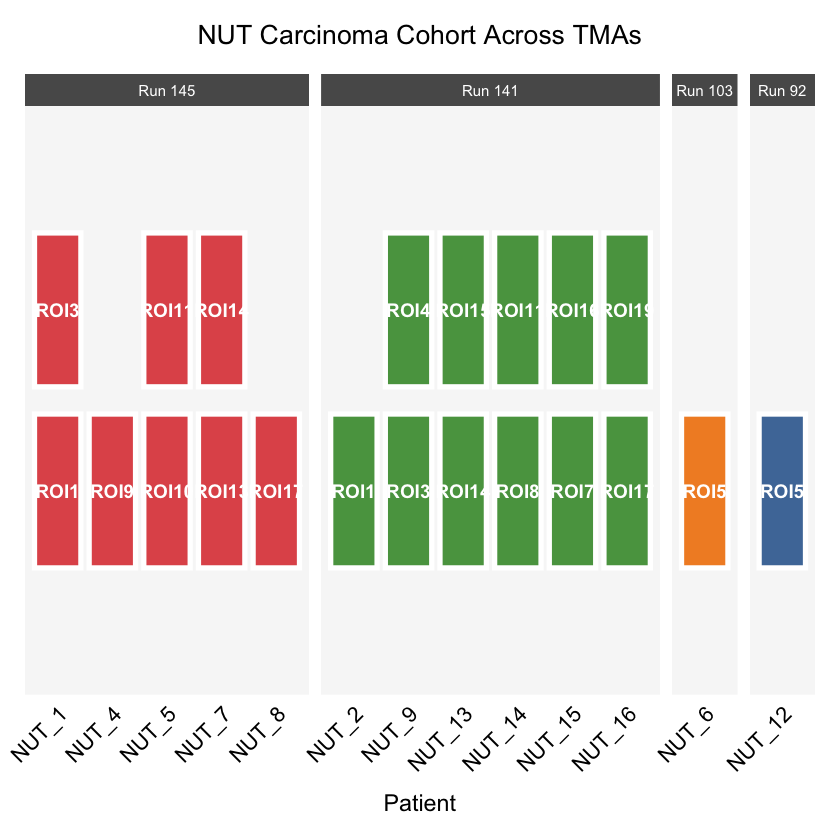

In [29]:
# TMA / Run Sample Distribution - Landscape (Run 145 first)
sample_dist_land <- celltype_metadata %>%
  select(patient_ID, patient_exp, run) %>%
  distinct() %>%
  mutate(
    tma = factor(paste0("Run ", run), levels = c("Run 145", "Run 141", "Run 103", "Run 92")),
    roi_label = str_extract(as.character(patient_exp), "ROI\\d+"),
    patient_num = as.numeric(str_extract(as.character(patient_ID), "\\d+"))
  ) %>%
  arrange(tma, patient_num) %>%
  group_by(patient_ID) %>%
  mutate(roi_pos = row_number()) %>%
  ungroup() %>%
  mutate(patient_ID = factor(patient_ID, levels = unique(patient_ID)))

tma_colors_land <- c(
  "Run 145" = "#E15759",
  "Run 141" = "#59A14F",
  "Run 103" = "#F28E2B",
  "Run 92"  = "#4E79A7"
)

tma_distribution_landscape <- ggplot(sample_dist_land, aes(x = patient_ID, y = roi_pos)) +
  geom_tile(aes(fill = tma), color = "white", linewidth = 1.5,
            width = 0.85, height = 0.85) +
  geom_text(aes(label = roi_label), color = "white", size = 4, fontface = "bold") +
  facet_grid(. ~ tma, scales = "free_x", space = "free_x") +
  scale_fill_manual(values = tma_colors_land) +
  scale_y_continuous(breaks = NULL, expand = expansion(add = 0.7)) +
  labs(
    title = "NUT Carcinoma Cohort Across TMAs",
    x = "Patient",
    y = NULL
  ) +
  theme_minimal(base_size = 13) +
  theme(
    plot.title = element_text(size = 16, colour = "black", hjust = 0.5,
                              margin = margin(b = 15)),
    axis.text.x = element_text(size = 13, colour = "black", angle = 45, hjust = 1),
    axis.title.x = element_text(size = 14, colour = "black", margin = margin(t = 10)),
    strip.text.x = element_text(size = 9, colour = "white"),
    strip.background = element_rect(fill = "grey35", color = NA),
    panel.grid = element_blank(),
    panel.background = element_rect(fill = "grey97", color = NA),
    panel.spacing = unit(0.5, "lines"),
    legend.position = "none",
    plot.margin = margin(15, 15, 15, 15)
  )

tma_distribution_landscape

ggsave(
  filename = file.path(results_dir, "run_sample_distribution_landscape.pdf"),
  plot = tma_distribution_landscape,
  width = 10,
  height = 4,
  dpi = 300,
  bg = "white"
)

# B

In [ ]:
# assuming niches_df has patient_exp and patient_ID (one row per ROI, or per cell -
# adjust distinct() accordingly)
roi_summary <- niches_df %>%
  distinct(patient_ID, patient_exp) %>%
  left_join(survival_df %>% distinct(patient_ID, tumor_site), by = "patient_ID")

# sanity check - make sure every ROI got a tumor_site (no NAs from a join mismatch)
sum(is.na(roi_summary$tumor_site))

site_counts <- roi_summary %>%
  group_by(tumor_site) %>%
  summarise(
    n_ROIs     = n(),
    n_patients = n_distinct(patient_ID)
  ) %>%
  ungroup() %>%
  pivot_longer(cols = c(n_ROIs, n_patients), names_to = "metric", values_to = "count") %>%
  mutate(metric = recode(metric, n_ROIs = "ROIs", n_patients = "Patients"))

site_counts

site_summary_plot <- ggplot(site_counts, aes(x = tumor_site, y = count, fill = metric)) +
  geom_col(position = position_dodge(width = 0.7), width = 0.6) +
  geom_text(aes(label = count), position = position_dodge(width = 0.7),
            vjust = -0.4, size = 4, color = "black") +
  scale_fill_manual(values = c("ROIs" = "#44AA99", "Patients" = "#88419D"), name = NULL) +
  theme_minimal() +
  labs(x = "Tumor site", y = "Count",
       title = paste0("Total: ", n_distinct(roi_summary$patient_ID), " patients, ",
                       nrow(roi_summary), " ROIs")) +
  theme(legend.position = "top",
        axis.text.x = element_text(color = "black", size = 12),
        axis.text.y = element_text(color = "black", size = 12),
        axis.title.x = element_text(color = "black", size = 13, margin = margin(t = 10)),
        axis.title.y = element_text(color = "black", size = 13, margin = margin(r = 10)),
        plot.title = element_text(size = 13, hjust = 0.5, margin = margin(b = 10)),
        axis.line.x.bottom = element_line(color = "black", size = 0.8),
        axis.line.y.left = element_line(color = "black", size = 0.8))

site_summary_plot

ggsave(
  filename = file.path(results_dir, "roi_patient_counts_by_tissue.pdf"),
  plot = site_summary_plot,
  width = 6, height = 5, dpi = 300, bg = "white"
)

# C

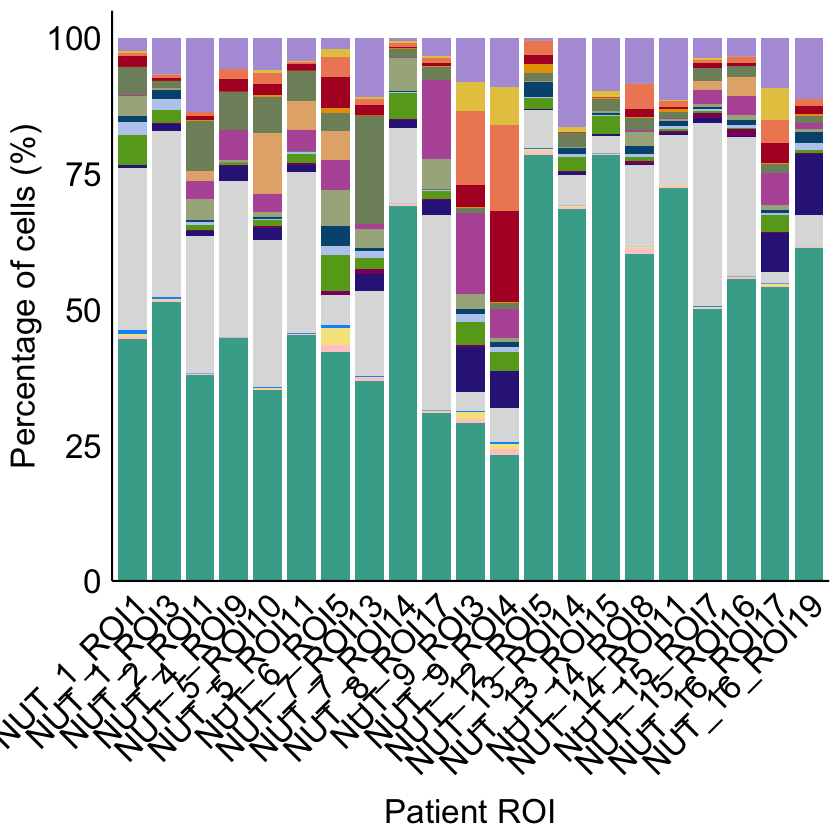

In [30]:
celltype_percentage_exp_plot = ggplot(
  celltype_percentage_exp,
  aes(x = patient_exp, y = percentage, fill = cell_category)
) +
  geom_bar(stat = "identity", width = 0.85) +
  scale_fill_manual(values = full_palette) +
  guides(fill = guide_legend(reverse = TRUE)) +
  labs(
    x = "Patient ROI",
    y = "Percentage of cells (%)",
    fill = "Cell type"
  ) +
  scale_y_continuous(limits = c(0, 105), expand = c(0, 0), sec.axis = dup_axis()) +
  theme_minimal(base_size = 13) +
  theme(
    axis.text.y = element_text(size = 20, colour = "black"),
    axis.text.x = element_text(size = 20, colour = "black", angle = 45, hjust = 1),
    axis.title.y = element_text(size = 20, colour = "black"),
    axis.title.x = element_text(size = 20, colour = "black", margin = margin(t = 10)),
    panel.border = element_blank(),
    axis.line.x.bottom = element_line(colour="black", linewidth=0.6),
    axis.line.x.top    = element_line(colour="black", linewidth=0.6),
    axis.line.y.left   = element_line(colour="black", linewidth=0.6),
    axis.line.y.right  = element_blank(),
    axis.text.x.top  = element_blank(),
    axis.ticks.x.top = element_blank(),
    axis.title.x.top = element_blank(),
    axis.ticks.y.right = element_blank(),
    axis.title.y.right = element_blank(),
    axis.text.y.right = element_blank(),
    panel.grid = element_blank(),
    legend.position = "none",
  )
celltype_percentage_exp_plot
ggsave(filename = file.path(results_dir, "celltype_percentage_exp_barplot.pdf"),
       plot = celltype_percentage_exp_plot,
       width = 12,
       height = 7,
       dpi = 300)

# D

In [31]:
#calculate celltype_proportions per patient_exp 
celltype_counts_exp <- celltype_metadata %>%
select(patient_exp, cell_category) %>%
group_by(patient_exp, cell_category) %>%
summarise(cell_count = n()) %>%
ungroup()

#Pivot wider for CLR
celltype_counts_wide <- celltype_counts_exp %>%
  pivot_wider(
    names_from = cell_category,
    values_from = cell_count,
    values_fill = 0
  ) %>%
  mutate(across(where(is.numeric), ~ .x + 1))

#Apply CLR per patient_exp
celltype_counts_clr <- celltype_counts_wide %>%
  rowwise() %>%
  mutate(across(where(is.numeric), ~ log(.x / exp(mean(log(c_across(where(is.numeric))))))))

#compute correlations between patient_exps based on their celltypes CLRs
celltype_clr_matrix <- celltype_counts_clr %>%
  select(-patient_exp) %>%
  as.matrix()
cor_matrix <- cor(t(celltype_clr_matrix), method = "pearson")
#add the patient_exp names as row and column names to the correlation matrix
rownames(cor_matrix) <- celltype_counts_clr$patient_exp
colnames(cor_matrix) <- celltype_counts_clr$patient_exp
#make self correlations NA
diag(cor_matrix) <- NA
cor_matrix

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by patient_exp and cell_category.
ℹ Output is grouped by patient_exp.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(patient_exp, cell_category))` for per-operation
  grouping (`?dplyr::dplyr_by`) instead.


,NUT_1_ROI1,NUT_1_ROI3,NUT_2_ROI1,NUT_4_ROI9,NUT_5_ROI10,NUT_5_ROI11,NUT_6_ROI5,NUT_7_ROI13,NUT_7_ROI14,NUT_8_ROI17,⋯,NUT_9_ROI4,NUT_12_ROI5,NUT_13_ROI14,NUT_13_ROI15,NUT_14_ROI8,NUT_14_ROI11,NUT_15_ROI7,NUT_15_ROI16,NUT_16_ROI17,NUT_16_ROI19
NUT_1_ROI1,NA,0.9278618,0.5366316,0.6159844,0.3995893,0.4317903,0.31357847,0.78409591,0.7720869,0.6888469,⋯,0.66051546,0.7325922,0.8381999,0.8090916,0.7691388,0.6661846,0.5539249,0.4757684,0.62508895,0.67348699
NUT_1_ROI3,0.9278618,NA,0.5397242,0.6356673,0.4048268,0.4355987,0.14175666,0.76502861,0.7282708,0.6189781,⋯,0.63601209,0.7640067,0.8791523,0.8150600,0.7924158,0.7446298,0.5561372,0.4721678,0.60506162,0.77583716
NUT_2_ROI1,0.5366316,0.5397242,NA,0.8010099,0.8389304,0.8868251,0.31774510,0.73529080,0.6596090,0.6506291,⋯,0.25841059,0.3613751,0.4751184,0.5094683,0.6391324,0.5306663,0.7615979,0.7884198,0.36816646,0.69191931
NUT_4_ROI9,0.6159844,0.6356673,0.8010099,NA,0.6665754,0.7055905,0.12558060,0.84210568,0.7475235,0.8580608,⋯,0.60323185,0.5812358,0.5119831,0.5572473,0.7921358,0.6602206,0.6556145,0.5950287,0.67643608,0.82491654
NUT_5_ROI10,0.3995893,0.4048268,0.8389304,0.6665754,NA,0.8886405,0.33351016,0.48744396,0.4957830,0.5634838,⋯,0.29208947,0.3100852,0.4516715,0.4857956,0.4627455,0.4879582,0.8300073,0.7407469,0.38913284,0.53897124
NUT_5_ROI11,0.4317903,0.4355987,0.8868251,0.7055905,0.8886405,NA,0.24120976,0.64076938,0.5878080,0.5716557,⋯,0.24505114,0.2371057,0.4291548,0.4581708,0.4244141,0.3924431,0.7782424,0.7369628,0.35556588,0.51179625
NUT_6_ROI5,0.3135785,0.1417567,0.3177451,0.1255806,0.3335102,0.2412098,NA,0.08787252,0.1535619,0.1684415,⋯,0.09437449,0.3981252,0.2171775,0.2618344,0.3449783,0.3165376,0.3393832,0.4572667,0.08153907,0.05658586
NUT_7_ROI13,0.7840959,0.7650286,0.7352908,0.8421057,0.4874440,0.6407694,0.08787252,NA,0.9041390,0.8162254,⋯,0.61401566,0.5804686,0.7004304,0.7396899,0.8242901,0.7046066,0.5463669,0.5006901,0.70550196,0.78114270
NUT_7_ROI14,0.7720869,0.7282708,0.6596090,0.7475235,0.4957830,0.5878080,0.15356190,0.90413895,NA,0.8328203,⋯,0.59730508,0.6464713,0.6788966,0.7856432,0.8108047,0.7187400,0.4817471,0.4021539,0.69840047,0.72723885
NUT_8_ROI17,0.6888469,0.6189781,0.6506291,0.8580608,0.5634838,0.5716557,0.16844146,0.81622535,0.8328203,NA,⋯,0.74671186,0.5257919,0.6038625,0.7007452,0.7656096,0.6885292,0.5906120,0.4735047,0.82221619,0.75703823


In [45]:
patient_id_vec <- str_extract(rownames(cor_matrix), "^NUT_\\d+")
patient_id_vec <- factor(patient_id_vec, levels = unique(patient_id_vec))

cor_matrix_main_ht <- Heatmap(
  cor_matrix,
  name = "Pearson Correlation",
  col = colorRamp2(c(0.7, 1), c("white", "red")),
  show_row_names = TRUE,
  show_column_names = TRUE,
  cluster_rows = FALSE,
  cluster_columns = FALSE,
  row_split = patient_id_vec,
  column_split = patient_id_vec,
  row_gap = unit(1.5, "mm"),
  column_gap = unit(1.5, "mm"),
  row_title = NULL,
  column_title = NULL,
  row_names_gp = gpar(fontsize = 11),
  column_names_gp = gpar(fontsize = 11),
  border = TRUE
)

pdf(paste0(results_dir, "/correlation_heatmap.pdf"), width = 9, height = 6.5)
draw(cor_matrix_main_ht)
dev.off()

agg_record_1fffffae03c 
                     2

# E

In [47]:
#turn this into a long df: cor_matrix_same_patient
cor_matrix_same_patient_long <- as.data.frame(as.table(cor_matrix_same_patient)) %>%
  rename(patient_exp1 = Var1, patient_exp2 = Var2, correlation = Freq) %>%
  filter(!is.na(correlation)) %>%
  #extract patient_ID
    mutate(patient_ID = str_extract(patient_exp1, "NUT_\\d+")) %>%
    select(patient_ID, correlation) %>%
    distinct()
cor_matrix_same_patient_long

patient_ID,correlation
<chr>,<dbl>
NUT_1,0.9278618
NUT_5,0.8886405
NUT_7,0.9041390
NUT_9,0.9110020
NUT_13,0.9478431
NUT_14,0.9118550
NUT_15,0.9386723
NUT_16,0.7426154


In [50]:
correlation_dotplot <- ggplot(cor_matrix_same_patient_long, aes(x = "", y = correlation)) +
  stat_summary(fun = mean, geom = "crossbar", width = 0.3, color = "#44AA99", linewidth = 0.6) +
  stat_summary(fun.data = mean_sdl, fun.args = list(mult = 1), geom = "errorbar",
               width = 0.15, color = "#44AA99", linewidth = 0.6) +
  geom_jitter(width = 0.08, color = "black", size = 2.5) +
  theme_minimal() +
  labs(x = "Patients with two ROIs", y = "Pearson's correlation between the two ROIs") +
  theme(axis.text.x = element_text(color = "black", size = 13),
        axis.title.x = element_text(color = "black", size = 13, margin = margin(t = 10)),
        axis.title.y = element_text(color = "black", size = 13, margin = margin(r = 10)),
        axis.text.y = element_text(color = "black", size = 13),
        axis.line.x.bottom = element_line(color = "black", size = 0.8),
        axis.line.y.left = element_line(color = "black", size = 0.8))

ggsave(
  filename = paste0(results_dir, "/correlation_dotplot.pdf"),
  plot = correlation_dotplot,
  width = 3,
  height = 5,
  dpi = 300
)

Warning message:
“Computation failed in `stat_summary()`.
Caused by error in `fun.data()`:
! The package "Hmisc" is required.”


# Figure 2

# A

n = 13  events = 12 
                is_lung n
1 Head and Neck/Abdomen 5
2                  Lung 8
Call:
coxph(formula = Surv(survival_time_months, event) ~ is_lung, 
    data = model_df)

  n= 13, number of events= 12 

              coef exp(coef) se(coef)     z Pr(>|z|)  
is_lungLung  2.685    14.660    1.091 2.462   0.0138 *
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

            exp(coef) exp(-coef) lower .95 upper .95
is_lungLung     14.66    0.06821     1.729     124.3

Concordance= 0.747  (se = 0.036 )
Likelihood ratio test= 9.98  on 1 df,   p=0.002
Wald test            = 6.06  on 1 df,   p=0.01
Score (logrank) test = 9.35  on 1 df,   p=0.002

        chisq df   p
is_lung 0.456  1 0.5
GLOBAL  0.456  1 0.5


Ignoring unknown labels:
• colour : "Primary tissue"
Ignoring unknown labels:
• colour : "Primary tissue"


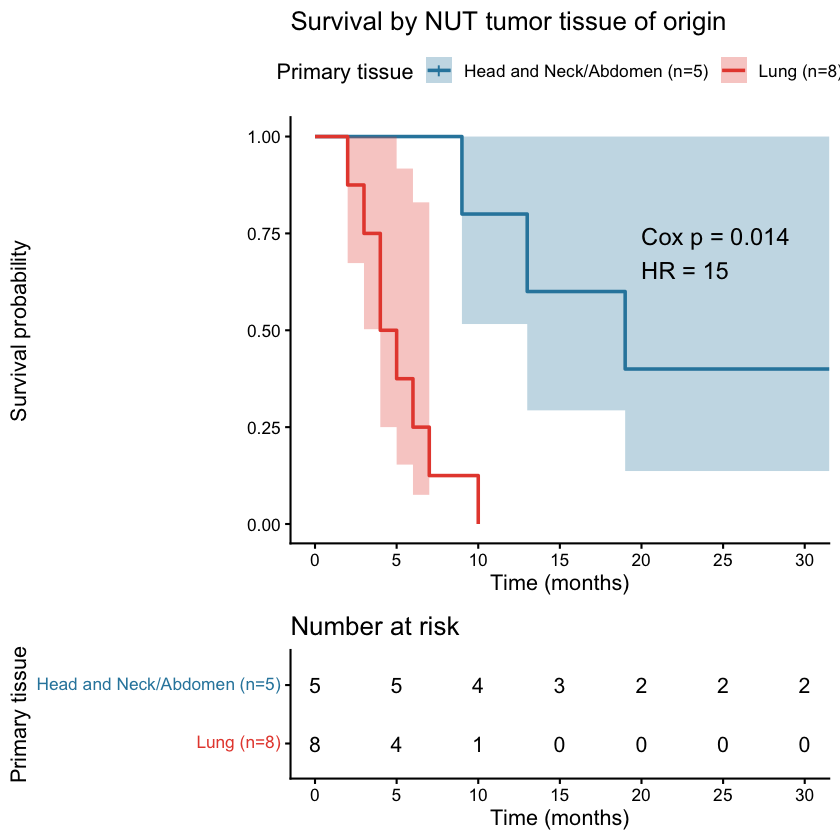

In [70]:
model_df <- survival_df %>%
    select(patient_ID, is_lung, event, survival_time_months) %>%
    mutate(is_lung = factor(is_lung, levels = c("Head and Neck/Abdomen", "Lung"))
    )

cat("n =", nrow(model_df), " events =", sum(model_df$event), "\n")
model_df %>% count(is_lung) %>% print()

fit_cox <- coxph(
  Surv(survival_time_months, event) ~ is_lung,
  data = model_df
)
print(summary(fit_cox))
print(cox.zph(fit_cox))

cox_p  <- summary(fit_cox)$coefficients["is_lungLung", "Pr(>|z|)"]
cox_hr <- summary(fit_cox)$coefficients["is_lungLung", "exp(coef)"]

fit_km <- survfit(Surv(survival_time_months, event) ~ is_lung, data = model_df)

n_lung <- sum(model_df$is_lung == "Lung")
n_nonlung <- sum(model_df$is_lung == "Head and Neck/Abdomen")

km <- ggsurvplot(
  fit_km,
  data        = model_df,
  pval        = paste0("Cox p = ", signif(cox_p, 2),
                       "\nHR = ", signif(cox_hr, 2)),
  pval.coord  = c(20, 0.7),
  conf.int    = TRUE,
  risk.table  = TRUE,
  risk.table.height = 0.28,
  palette     = c("#2E86AB", "#E74C3C"),
  xlab        = "Time (months)",
  ylab        = "Survival probability",
  title       = "Survival by NUT tumor tissue of origin",
  legend.title = "Primary tissue",
  legend.labs  = c(paste0("Head and Neck/Abdomen (n=", n_nonlung, ")"),
                   paste0("Lung (n=", n_lung, ")")),
    xlim        = c(0, 30),          # zoom to where events happen
  break.time.by = 5,              # ticks every 10 months
  ggtheme     = theme_classic(base_size = 13)
)
km

ggsave(file.path(results_dir, "KM_lungnolung.pdf"),
       plot = km$plot, width = 7, height = 5, dpi = 300, bg = "white")
ggsave(file.path(results_dir, "KM_lungnolung_table.pdf"),
       plot = km$table, width = 7, height = 2, dpi = 300, bg = "white")

# B

Warning message:
“Computation failed in `stat_summary()`.
Caused by error in `fun.data()`:
! The package "Hmisc" is required.”
Warning message:
“Computation failed in `stat_summary()`.
Caused by error in `fun.data()`:
! The package "Hmisc" is required.”
Warning message:
“Computation failed in `stat_summary()`.
Caused by error in `fun.data()`:
! The package "Hmisc" is required.”
Warning message:
“Computation failed in `stat_summary()`.
Caused by error in `fun.data()`:
! The package "Hmisc" is required.”
Warning message:
“Computation failed in `stat_summary()`.
Caused by error in `fun.data()`:
! The package "Hmisc" is required.”
Warning message:
“Computation failed in `stat_summary()`.
Caused by error in `fun.data()`:
! The package "Hmisc" is required.”
Warning message:
“Computation failed in `stat_summary()`.
Caused by error in `fun.data()`:
! The package "Hmisc" is required.”
Warning message:
“Computation failed in `stat_summary()`.
Caused by error in `fun.data()`:
! The package "Hmisc

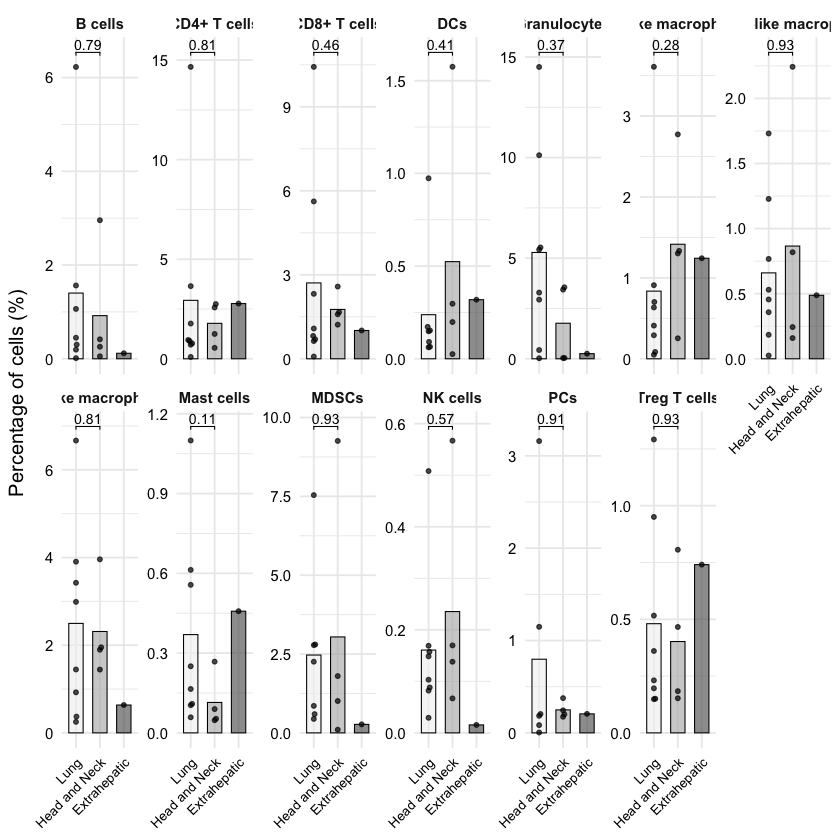

In [79]:
celltype_pct_site <- celltype_percentage_patient %>%
  left_join(survival_df %>% distinct(patient_ID, tumor_site), by = "patient_ID") %>%
  filter(cell_category %in% c(names(myeloid_palette), names(lymphoid_palette)))

celltype_by_site_plot <- ggplot(celltype_pct_site, aes(x = tumor_site, y = percentage, fill = tumor_site)) +
  stat_summary(fun = mean, geom = "col", alpha = 0.6, width = 0.6, color = "black", linewidth = 0.3) +
  stat_summary(fun.data = mean_sdl, fun.args = list(mult = 1), geom = "errorbar",
               width = 0.25, linewidth = 0.5, color = "black") +
  geom_beeswarm(size = 1, cex = 2, color = "black", alpha = 0.7) +
  facet_wrap(~ cell_category, scales = "free_y", ncol = 7) +
  stat_compare_means(
    method = "wilcox.test",
    comparisons = list(c("Lung", "Head and Neck")),
    size = 3, tip.length = 0.01, label = "p.format"
  ) +
  scale_fill_manual(values = tumor_site_colors) +
  theme_minimal(base_size = 11) +
  labs(x = NULL, y = "Percentage of cells (%)") +
  theme(legend.position = "none",
        axis.text.x = element_text(color = "black", size = 8, angle = 45, hjust = 1),
        axis.text.y = element_text(color = "black", size = 9),
        strip.text = element_text(size = 9, face = "bold"),
        axis.title.y = element_text(size = 12, margin = margin(r = 10)))

celltype_by_site_plot

ggsave(
  filename = file.path(results_dir, "celltype_abundance_by_tumorsite.pdf"),
  plot = celltype_by_site_plot,
  width = 15, height = 8, dpi = 300, bg = "white"
)

# Supp 3

## A

In [90]:
make_celltype_boxplot <- function(df, categories, palette, title = NULL) {

  plot_df <- df %>%
    filter(cell_category %in% categories) %>%
    mutate(cell_category = droplevels(factor(cell_category, levels = categories)))

  order_levels <- plot_df %>%
    group_by(cell_category) %>%
    summarise(med = median(percentage, na.rm = TRUE)) %>%
    arrange(desc(med)) %>%
    pull(cell_category)

  plot_df <- plot_df %>%
    mutate(cell_category = factor(cell_category, levels = order_levels))

  stat_res <- plot_df %>%
    wilcox_test(percentage ~ cell_category) %>%
    add_significance("p") %>%
    filter(p < 0.05) %>%
    # clean, consistent p-value formatting - no scientific notation
    mutate(p.label = paste0("p ", ifelse(p < 0.001, "< 0.001", paste0("= ", formatC(p, digits = 3, format = "f"))))) %>%
    add_xy_position(x = "cell_category", step.increase = 0.12)   # more vertical spacing

  y_max <- max(stat_res$y.position, na.rm = TRUE)

  ggplot(plot_df, aes(x = cell_category, y = percentage, fill = cell_category)) +
    geom_boxplot(outlier.shape = NA, alpha = 0.85, color = "black", linewidth = 0.4) +
    geom_jitter(width = 0.15, size = 1.3, color = "black", alpha = 0.7) +
    stat_pvalue_manual(stat_res, label = "p.label", tip.length = 0.005,
                        size = 3.2, bracket.size = 0.35) +
    scale_fill_manual(values = palette) +
    scale_y_continuous(expand = expansion(mult = c(0.02, 0.08)),
                        limits = c(0, y_max * 1.1)) +           # headroom so top brackets aren't clipped
    theme_minimal(base_size = 12) +
    labs(x = NULL, y = "% of all cells", title = title) +
    theme(legend.position = "none",
          axis.text.x = element_text(color = "black", size = 10, angle = 45, hjust = 1),
          axis.text.y = element_text(color = "black", size = 10),
          axis.title.y = element_text(size = 12, margin = margin(r = 10)),
          plot.title = element_text(size = 13, hjust = 0.5, margin = margin(b = 10)))
}

myeloid_plot <- make_celltype_boxplot(celltype_percentage_patient, names(myeloid_palette), myeloid_palette, "Myeloid cell type")
lymphoid_plot <- make_celltype_boxplot(celltype_percentage_patient, names(lymphoid_palette), lymphoid_palette, "Lymphoid cell type")

combined_myeloid_lymphoid <- myeloid_plot + lymphoid_plot + plot_layout(ncol = 2)

# taller output so stacked brackets have room to breathe
ggsave(
  filename = file.path(results_dir, "myeloid_lymphoid_abundance_boxplots.pdf"),
  plot = combined_myeloid_lymphoid,
  width = 15, height = 9, dpi = 300, bg = "white"
)

# B-C

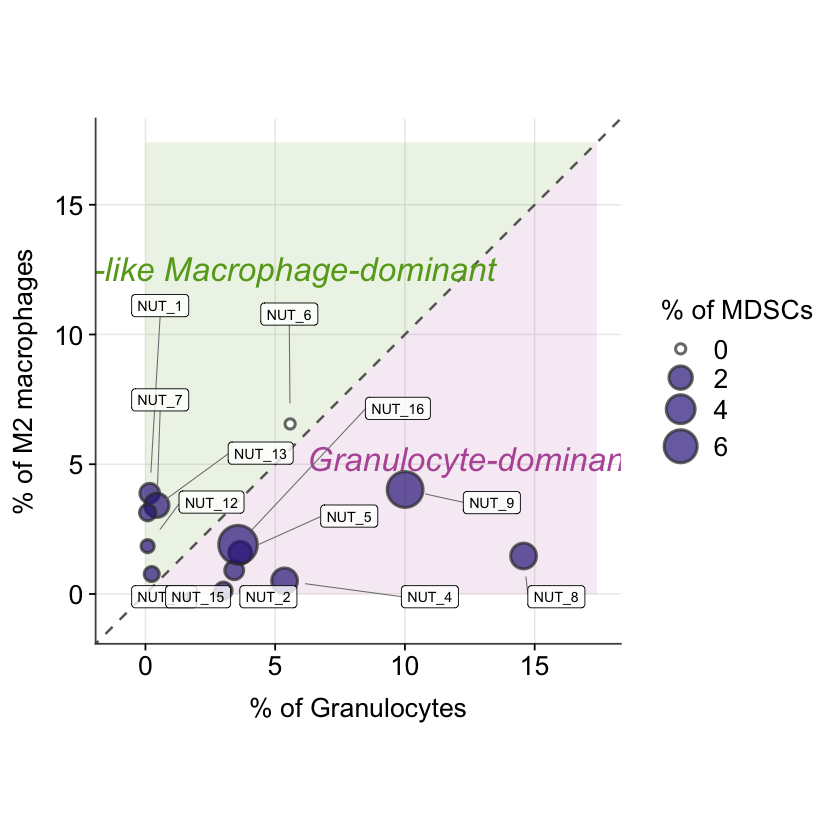

In [96]:
scatter_df <- celltype_percentage_patient %>%
  filter(cell_category %in% c("Granulocytes", "M2-like macrophages", "MDSCs")) %>%
  select(patient_ID, cell_category, percentage) %>%
  pivot_wider(names_from = cell_category, values_from = percentage) %>%
  rename(
    granulocytes = Granulocytes,
    m2_macro     = `M2-like macrophages`,
    mdscs        = MDSCs
  ) %>%
  mutate(
    mdscs    = replace_na(mdscs, 0),
    dominant = ifelse(granulocytes >= m2_macro, "gran", "m2")
  )

ax_max <- max(scatter_df$granulocytes, scatter_df$m2_macro) * 1.2

ggplot(scatter_df, aes(x = granulocytes, y = m2_macro)) +

  # shaded triangles
  annotate("polygon",
           x = c(0, ax_max, ax_max),
           y = c(0, 0,      ax_max),
           fill = full_palette["Granulocytes"], alpha = 0.12) +
  annotate("polygon",
           x = c(0, 0,      ax_max),
           y = c(0, ax_max, ax_max),
           fill = full_palette["M2-like macrophages"], alpha = 0.12) +

  # diagonal
  geom_abline(slope = 1, intercept = 0,
              linetype = "dashed", color = "grey40", linewidth = 0.7) +

  # region labels
  annotate("text",
           x = ax_max * 0.72, y = ax_max * 0.30,
           label = "Granulocyte-dominant",
           color = full_palette["Granulocytes"],
           size = 7, fontface = "italic") +
  annotate("text",
           x = ax_max * 0.28, y = ax_max * 0.72,
           label = "M2-like Macrophage-dominant",
           color = full_palette["M2-like macrophages"],
           size = 7, fontface = "italic") +

  # points
  geom_point(aes(size = mdscs,
                 fill = ifelse(mdscs == 0, "white", full_palette["MDSCs"])),
             shape    = 21,
             color    = "grey20",
             alpha    = 0.7,
             stroke   = 1.3,
             position = position_jitter(width = 0.15, height = 0.15, seed = 42)) +

  scale_fill_identity() +
  scale_size_continuous(
    name   = "% of MDSCs",
    range  = c(2, 10),
    breaks = c(0, 2, 4, 6)
  ) +

  guides(
    size = guide_legend(
      override.aes = list(
        fill  = c("white", full_palette["MDSCs"], full_palette["MDSCs"], full_palette["MDSCs"]),
        color = "grey20"
      )
    ),
    fill = "none"
  ) +

  # single geom_label_repel — no xlim/ylim constraints, just maximum repulsion
  geom_label_repel(
    aes(label = patient_ID),
    size               = 3,
    fill               = alpha("white", 0.80),
    label.size         = 0.2,
    box.padding        = 1.5,
    point.padding      = 0.8,
    max.overlaps       = Inf,
    force              = 15,
    force_pull         = 0.1,
    min.segment.length = 0,
    segment.color      = "grey50",
    segment.size       = 0.3,
    seed               = 42,
    position           = position_jitter(width = 0.15, height = 0.15, seed = 42)
  ) +

  coord_fixed(ratio = 1,
              xlim  = c(-1, ax_max),
              ylim  = c(-1, ax_max)) +

  labs(
    x = "% of Granulocytes",
    y = "% of M2 macrophages"
  ) +

  theme_classic(base_size = 16) +
  theme(
    legend.position  = "right",
    legend.title     = element_text(size = 16),
    legend.text      = element_text(size = 16),
    axis.text.x      = element_text(size = 16, colour = "black"),
    axis.title.x     = element_text(size = 16, colour = "black", margin = margin(t = 10)),
    axis.text.y      = element_text(size = 16, colour = "black"),
    axis.title.y     = element_text(size = 16, colour = "black", margin = margin(r = 10)),
    axis.line        = element_line(linewidth = 0.5, colour = "grey30"),
    axis.ticks       = element_line(linewidth = 0.5, colour = "black"),
    panel.grid.major = element_line(color = "grey92", linewidth = 0.4)
  )

ggsave(filename = paste0(results_dir, "/granulocyte_m2_macro_scatter.pdf"),
       width = 10, height = 8, dpi = 300, bg = "white")

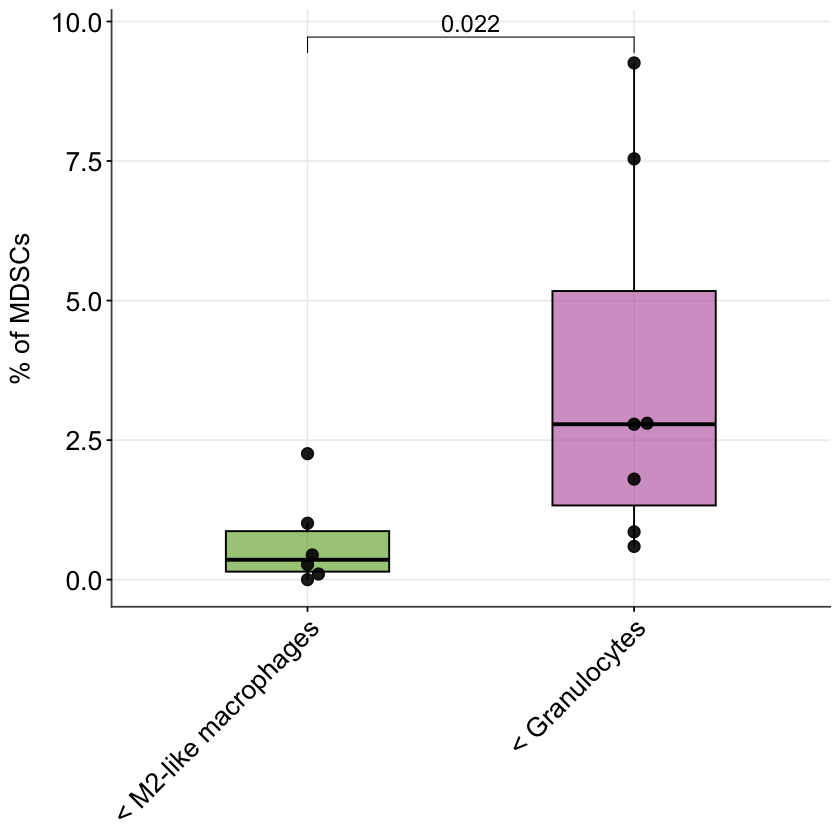

In [107]:
 scatter_df <- celltype_percentage_patient %>%
  filter(cell_category %in% c("Granulocytes", "M2-like macrophages", "MDSCs")) %>%
  select(patient_ID, cell_category, percentage) %>%
  pivot_wider(names_from = cell_category, values_from = percentage) %>%
  rename(
    granulocytes = Granulocytes,
    m2_macro     = `M2-like macrophages`,
    mdscs        = MDSCs
  ) %>%
  mutate(
    mdscs    = replace_na(mdscs, 0),
    dominant = ifelse(granulocytes >= m2_macro, "gran", "m2")
  )

# Classify patients
mdsc_compare_df <- scatter_df %>%
  select(patient_ID, granulocytes, m2_macro, mdscs, dominant) %>%
  mutate(
    dominant_label = ifelse(dominant == "gran",
                            "< Granulocytes",
                            "< M2-like macrophages")
  ) %>%
  mutate(dominant_label = factor(dominant_label, levels = c("< M2-like macrophages", "< Granulocytes")))

comparisons <- list(c("< M2-like macrophages", "< Granulocytes"))

ggplot(mdsc_compare_df, aes(x = dominant_label, y = mdscs, fill = dominant_label)) +

  geom_boxplot(
    width         = 0.5,
    alpha         = 0.6,
    color         = "black",
    outlier.shape = NA
  ) +

  geom_beeswarm(
    size  = 3,
    alpha = 0.9,
    color = "black",
    cex   = 2
  ) +

  stat_compare_means(
    comparisons = comparisons,
    method      = "wilcox.test",
    label       = "p.format",
    paired      = FALSE,
    size        = 5
  ) +

  scale_fill_manual(values = gvsm2_colors) +
  
  labs(
    x = NULL,
    y = "% of MDSCs"
  ) +

  theme_classic(base_size = 12) +
  theme(
    legend.position  = "none",
    axis.text.x      = element_text(size = 16, colour = "black", angle = 45, hjust = 1),
    axis.text.y      = element_text(size = 16, colour = "black"),
    axis.title.y     = element_text(size = 16, colour = "black", margin = margin(r = 10)),
    axis.line        = element_line(linewidth = 0.5, colour = "grey30"),
    axis.ticks       = element_line(linewidth = 0.5, colour = "black"),
    panel.grid.major = element_line(color = "grey92", linewidth = 0.4)
  )

ggsave(filename = paste0(results_dir, "/mdsc_gran_vs_m2_boxplot.pdf"),
       width = 6, height = 6, dpi = 300, bg = "white")

# S4

# A-B from niche analysis ...

# The rest from Figure 5 KM curves

# S5 

# A

In [118]:
# order cell_category from smallest to largest median distance (across all patients)
cell_order <- distances_squidpy_endo %>%
  group_by(cell_category) %>%
  summarise(med = median(distance_µm, na.rm = TRUE)) %>%
  arrange(med) %>%
  pull(cell_category)

distance_plot_df <- distances_squidpy_endo %>%
  mutate(cell_category = factor(cell_category, levels = cell_order)) %>%
  filter(n_cells > 10)

p <- ggplot(
  distance_plot_df,
  aes(x = cell_category, y = distance_µm, fill = cell_category)
) +
  geom_boxplot(
    outlier.shape = NA,
    width         = 0.6,
    alpha         = 0.6,
    color         = "black"
  ) +
  geom_beeswarm(
    cex   = 2.5,
    size  = 1.8,
    alpha = 0.8,
    color = "black"
  ) +
  scale_y_log10() +
  scale_fill_manual(values = full_palette) +
  labs(
    x     = NULL,
    y     = "Distance to nearest Endothelial cell (µm)",
    title = "Average distance to Endothelial cells across immune cell populations"
  ) +
  theme_classic() +
  theme(
    legend.position  = "none",
    plot.title       = element_text(size = 16, face = "plain", colour = "black",
                                     hjust = 0.5),
    axis.text.x      = element_text(angle = 45, hjust = 1, size = 16,
                                     colour = "black"),
    axis.text.y      = element_text(size = 16, colour = "black"),
    axis.title.y     = element_text(size = 16, colour = "black",
                                     margin = margin(r = 10)),
    axis.line        = element_line(linewidth = 0.5, colour = "black"),
    axis.ticks       = element_line(linewidth = 0.5, colour = "black"),
    plot.margin      = margin(t = 10, r = 15, b = 5, l = 5)
  )

ggsave(
  filename = file.path(results_dir, "distance_to_endo_all_celltypes.pdf"),
  plot     = p,
  width    = length(cell_order) * 0.8,
  height   = 6,
  dpi      = 300,
  bg       = "white"
)

# B

In [117]:
myeloid_select <- c("Granulocytes", "MDSCs", "M2-like macrophages")

# Build combined dataset
distances_all <- map_dfr(myeloid_select, function(ct) {
  distances_squidpy_endo %>%
    filter(cell_category %in% c(ct, "CD4+ T cells", "CD8+ T cells")) %>%
    mutate(
      cell_category    = factor(cell_category,
                                levels = c("CD4+ T cells", "CD8+ T cells", ct)),
      comparison_group = ct
    )
})

# perform paired wilcox testing (joined by patient_ID to guarantee correct pairing)
pval_df <- map_dfr(myeloid_select, function(ct) {
  map_dfr(c("CD4+ T cells", "CD8+ T cells"), function(tcell) {

    tcell_dat    <- distances_squidpy_endo %>% filter(cell_category == tcell)
    myeloid_dat  <- distances_squidpy_endo %>% filter(cell_category == ct)

    paired_dat <- inner_join(
      tcell_dat   %>% select(patient_ID, tcell_val = distance_µm),
      myeloid_dat %>% select(patient_ID, myeloid_val = distance_µm),
      by = "patient_ID"
    ) %>% filter(!is.na(tcell_val) & !is.na(myeloid_val))

    p <- wilcox.test(paired_dat$tcell_val, paired_dat$myeloid_val, paired = TRUE)$p.value

    tibble(
      comparison_group = ct,
      tcell            = tcell,
      p.value          = p,
      p.format         = paste0("p = ", signif(p, 2)),
      n_paired         = nrow(paired_dat)
    )
  })
})

# only keep significant
sig_comparisons <- pval_df %>%
  filter(p.value < 0.05) %>%
  mutate(y_position = ifelse(tcell == "CD8+ T cells", log10(110), log10(140)))

# plotting
p <- ggplot(
  distances_all,
  aes(x = cell_category, y = distance_µm, fill = cell_category)
) +
  geom_boxplot(
    outlier.shape = NA,
    width         = 0.6,
    alpha         = 0.6,
    color         = "black"
  ) +
  geom_beeswarm(
    cex   = 2.5,
    size  = 1.8,
    alpha = 0.8,
    color = "black"
  ) +
  {if (nrow(sig_comparisons) > 0)
    geom_signif(
      data        = sig_comparisons,
      aes(
        xmin        = tcell,
        xmax        = comparison_group,
        annotations = p.format,
        y_position  = y_position
      ),
      inherit.aes = FALSE,
      manual      = TRUE,
      textsize    = 4,
      tip_length  = 0.01
    )
  } +
  scale_fill_manual(values = full_palette) +
  scale_y_log10(limits = c(NA, 150)) +
  facet_wrap(~ comparison_group, nrow = 1, scales = "free_x") +
  labs(
    x     = NULL,
    y     = "Distance to nearest Endothelial cell (µm)",
    title = "Average distance to Endothelial cells from the selected myeloid cells"
  ) +
  theme_classic() +
  theme(
    legend.position  = "none",
    plot.title       = element_text(size = 16, face = "plain", colour = "black",
                                     hjust = 0.5),
    strip.background = element_blank(),
    strip.text       = element_text(size = 16, face = "plain", colour = "black"),
    panel.spacing    = unit(1.2, "lines"),
    axis.text.x      = element_text(angle = 45, hjust = 1, size = 16,
                                     colour = "black"),
    axis.text.y      = element_text(size = 16, colour = "black"),
    axis.title.y     = element_text(size = 16, colour = "black",
                                     margin = margin(r = 10)),
    axis.line        = element_line(linewidth = 0.5, colour = "black"),
    axis.ticks       = element_line(linewidth = 0.5, colour = "black"),
    plot.margin      = margin(t = 10, r = 15, b = 5, l = 5)
  )

ggsave(
  filename = file.path(results_dir, "distance_CD8_CD4_vs_3_myeloid_endo.pdf"),
  plot     = p,
  width    = length(myeloid_select) * 3,
  height   = 6,
  dpi      = 300,
  bg       = "white"
)

Warning message in geom_signif(data = sig_comparisons, aes(xmin = tcell, xmax = comparison_group, :
“Ignoring unknown aesthetics: xmin, xmax, annotations, and y_position”
Warning message:
“Removed 4 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range
(`geom_point()`).”


# C illustrated

# D from figure 6

# S6

# A from cozi 

# B

In [120]:
library(dplyr); library(tidyr); library(purrr); library(survival); library(survminer)

# ---- thresholds (pre-specified, biologically motivated) ----
DIFF_MIN    <- 1
REQUIRE_POS <- TRUE

# ---- the four suppressive -> cytotoxic pairs ----
pair_specs <- list(
  list(supp = "M2-like macrophages", targ = "CD4+ T cells", tag = "M2_CD4"),
  list(supp = "M2-like macrophages", targ = "CD8+ T cells", tag = "M2_CD8"),
  list(supp = "Granulocytes",        targ = "CD4+ T cells", tag = "Gran_CD4"),
  list(supp = "Granulocytes",        targ = "CD8+ T cells", tag = "Gran_CD8")
)

run_interaction_km <- function(supp, targ, tag) {

  fwd <- paste0(supp, "-", targ)   # suppressive -> target (suppressive direction)
  rev <- paste0(targ, "-", supp)   # target -> suppressive

  # ---- per-patient interaction table, both directions ----
  dat <- interaction_df %>%
    filter(cell_pair %in% c(fwd, rev)) %>%
    select(patient_ID, cell_pair, zscore) %>%
    pivot_wider(names_from = cell_pair, values_from = zscore)

  # guard: if a direction is entirely absent, skip
  if (!all(c(fwd, rev) %in% names(dat))) {
    cat("SKIP", tag, "- missing one direction in interaction_df\n"); return(invisible(NULL))
  }

  dat <- dat %>%
    mutate(supp_to_targ = .data[[fwd]],
           targ_to_supp = .data[[rev]],
           zscore_diff  = supp_to_targ - targ_to_supp) %>%
    left_join(survival_df, by = "patient_ID")

  model_df <- dat %>%
    filter(!is.na(zscore_diff), !is.na(survival_time_months), !is.na(event)) %>%
    mutate(is_high  = (zscore_diff >= DIFF_MIN) & (!REQUIRE_POS | supp_to_targ > 0),
           grp = factor(ifelse(is_high, "High", "Low"), levels = c("Low", "High")))

  cat("\n===", tag, "(", supp, "->", targ, ") ===\n")
  cat("n =", nrow(model_df), " events =", sum(model_df$event), "\n")
  print(table(model_df$grp))

  tab <- table(model_df$grp)
  if (length(tab) < 2 || any(tab < 2)) {
    cat("SKIP", tag, "- degenerate split (", paste(names(tab), tab, collapse=", "), ")\n")
    return(invisible(NULL))
  }

  fit_cox <- coxph(Surv(survival_time_months, event) ~ grp, data = model_df)
  s <- summary(fit_cox)
  cox_p  <- s$coefficients["grpHigh", "Pr(>|z|)"]
  cox_hr <- s$coefficients["grpHigh", "exp(coef)"]
  ph_p   <- tryCatch(cox.zph(fit_cox)$table[1, "p"], error = function(e) NA_real_)
  cat(sprintf("HR=%.2f  p=%.3f  PH_p=%.3f\n", cox_hr, cox_p, ph_p))

  fit_km <- survfit(Surv(survival_time_months, event) ~ grp, data = model_df)
  n_high <- sum(model_df$grp == "High"); n_low <- sum(model_df$grp == "Low")

  km <- ggsurvplot(
    fit_km, data = model_df,
    pval = paste0("Cox p = ", signif(cox_p, 2), "\nHR = ", signif(cox_hr, 2)),
    pval.coord = c(20, 0.7), conf.int = TRUE,
    risk.table = TRUE, risk.table.height = 0.28,
    palette = c("#2E86AB", "#E74C3C"),
    xlab = "Time (months)", ylab = "Survival probability",
    title = paste0("Survival by ", supp, "\u2013", targ, " neighbor preference"),
    legend.title = paste0(supp, "\u2013", targ, " NEP"),
    legend.labs = c(paste0("Low (n=", n_low, ")"), paste0("High (n=", n_high, ")")),
    xlim = c(0, 30), break.time.by = 5,
    ggtheme = theme_classic(base_size = 13))

  ggsave(file.path(results_dir, paste0("KM_", tag, "_prespecified_split.pdf")),
         plot = km$plot,  width = 7, height = 5, dpi = 300, bg = "white", device = cairo_pdf)
  ggsave(file.path(results_dir, paste0("KM_", tag, "_prespecified_split_table.pdf")),
         plot = km$table, width = 7, height = 2, dpi = 300, bg = "white", device = cairo_pdf)

  tibble(pair = tag, supp = supp, targ = targ,
         HR = cox_hr, p = cox_p, ph_p = ph_p, n = nrow(model_df),
         n_high = n_high, n_low = n_low)
}

# ---- run all four, collect a summary table ----
results_summary <- map_dfr(pair_specs, ~ run_interaction_km(.x$supp, .x$targ, .x$tag))
print(results_summary)


=== M2_CD4 ( M2-like macrophages -> CD4+ T cells ) ===
n = 13  events = 12 

 Low High 
   9    4 
HR=0.77  p=0.672  PH_p=0.560


Ignoring unknown labels:
• colour : "M2-like macrophages–CD4+ T cells NEP"



=== M2_CD8 ( M2-like macrophages -> CD8+ T cells ) ===
n = 13  events = 12 

 Low High 
   9    4 
HR=0.77  p=0.685  PH_p=0.794


Ignoring unknown labels:
• colour : "M2-like macrophages–CD8+ T cells NEP"



=== Gran_CD4 ( Granulocytes -> CD4+ T cells ) ===
n = 10  events = 10 

 Low High 
   6    4 
HR=1.17  p=0.817  PH_p=0.656


...


=== Gran_CD8 ( Granulocytes -> CD8+ T cells ) ===
n = 10  events = 10 

 Low High 
   8    2 


Warning message in coxph.fit(X, Y, istrat, offset, init, control, weights = weights, :
“Loglik converged before variable  1 ; coefficient may be infinite. ”


HR=2267796636.28  p=0.999  PH_p=1.000


Ignoring unknown labels:
• colour : "Granulocytes–CD8+ T cells NEP"


# A tibble: 4 × 9
  pair     supp                targ            HR     p  ph_p     n n_high n_low
  <chr>    <chr>               <chr>        <dbl> <dbl> <dbl> <int>  <int> <int>
1 M2_CD4   M2-like macrophages CD4+ T ce… 7.67e-1 0.672 0.560    13      4     9
2 M2_CD8   M2-like macrophages CD8+ T ce… 7.75e-1 0.685 0.794    13      4     9
3 Gran_CD4 Granulocytes        CD4+ T ce… 1.17e+0 0.817 0.656    10      4     6
4 Gran_CD8 Granulocytes        CD8+ T ce… 2.27e+9 0.999 1.000    10      2     8
